In [25]:
import subprocess
result = subprocess.run(["pip", "install", "torch"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



In [24]:
import torch
print("PyTorch version:", torch.__version__)


PyTorch version: 2.12.0+cpu


In [26]:
!pip install numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix

print("All libraries loaded!")

All libraries loaded!


In [33]:
# MNIST dataset download and load 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download automatically
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Make DataLoader 
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f"Train images: {len(train_data)}")
print(f"Test images:  {len(test_data)}")
print("Dataset loaded successfully!")

Train images: 60000
Test images:  10000
Dataset loaded successfully!


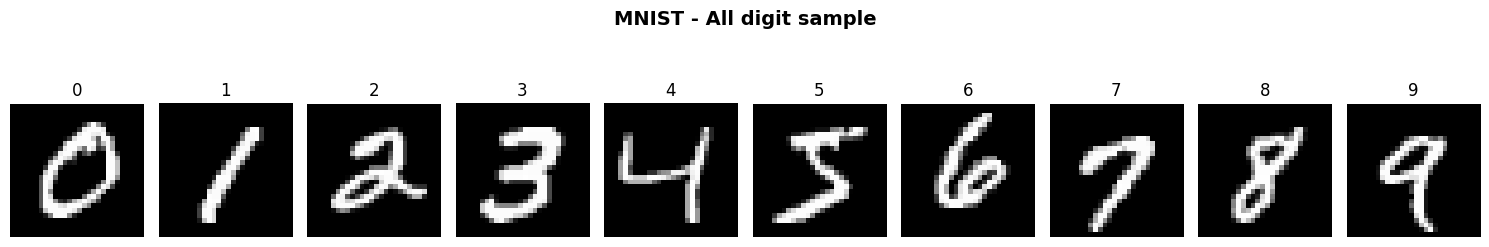

Sample images displayed!


In [30]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
fig.suptitle("MNIST - All digit sample", fontsize=14, fontweight="bold")

for digit in range(10):
    idx = (train_data.targets == digit).nonzero()[0][0]
    img = train_data.data[idx].numpy()
    
    axes[digit].imshow(img, cmap="gray")
    axes[digit].set_title(f"{digit}", fontsize=12)
    axes[digit].axis("off")

plt.tight_layout()
plt.show()
print("Sample images displayed!")

In [31]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        #  First Convolutional Block 
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)
        
        #  Second Convolutional Block 
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)
        
        # Fully Connected
        self.fc1   = nn.Linear(64 * 7 * 7, 256)
        self.drop3 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 10)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

model     = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN Model ready!")
print(model)
        

CNN Model ready!
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (drop3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [32]:
epochs = 10
train_losses = []
train_accuracies = []

print("Training started...")
print("-" * 40)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("-" * 40)
print("Training Finished!")

Training started...
----------------------------------------
Epoch 1/10 | Loss: 0.1878 | Accuracy: 94.18%
Epoch 2/10 | Loss: 0.0681 | Accuracy: 97.97%
Epoch 3/10 | Loss: 0.0492 | Accuracy: 98.50%
Epoch 4/10 | Loss: 0.0439 | Accuracy: 98.66%
Epoch 5/10 | Loss: 0.0380 | Accuracy: 98.89%
Epoch 6/10 | Loss: 0.0353 | Accuracy: 98.98%
Epoch 7/10 | Loss: 0.0313 | Accuracy: 99.05%
Epoch 8/10 | Loss: 0.0292 | Accuracy: 99.10%
Epoch 9/10 | Loss: 0.0265 | Accuracy: 99.19%
Epoch 10/10 | Loss: 0.0247 | Accuracy: 99.26%
----------------------------------------
Training Finished!


In [34]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

test_acc = 100 * correct / total
print(f" Test Accuracy: {test_acc:.2f}%")
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds))

 Test Accuracy: 99.48%

Detailed Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       0.99      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      1.00      1028
           8       0.99      0.99      0.99       974
           9       0.99      1.00      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



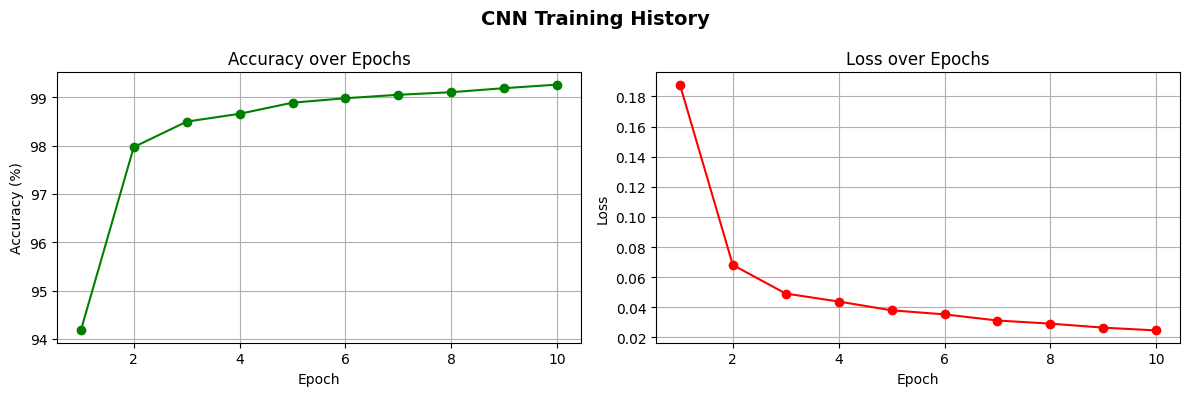

Training graphs displayed!


In [35]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), train_accuracies, color="green", marker="o")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), train_losses, color="red", marker="o")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.suptitle("CNN Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Training graphs displayed!")

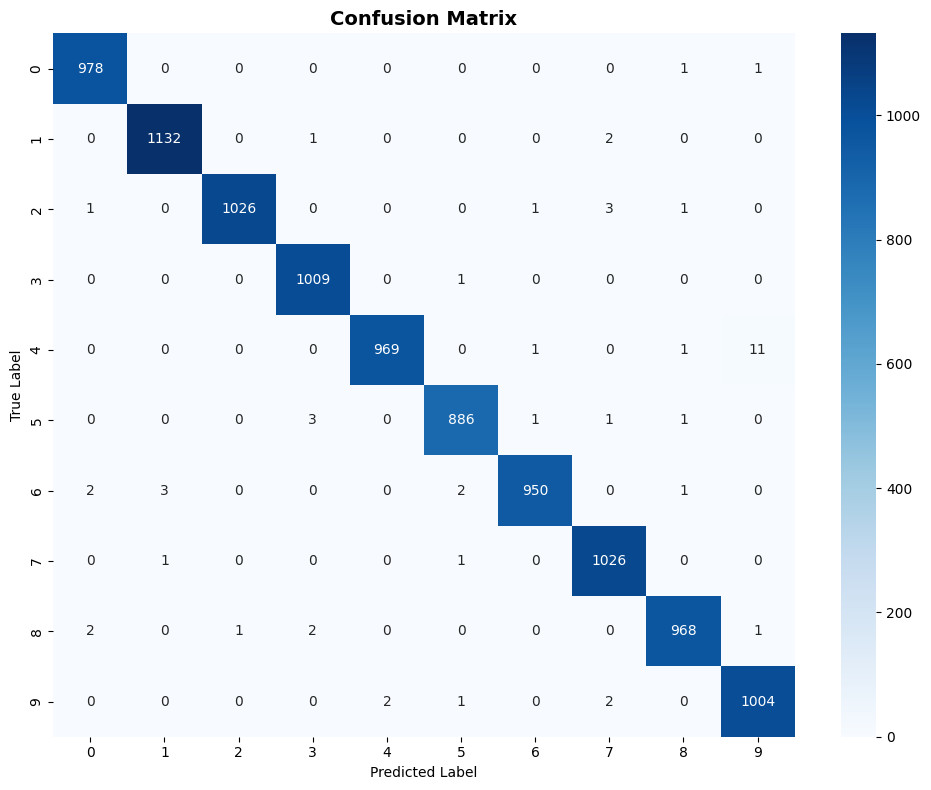

Confusion matrix displayed!


In [36]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
print("Confusion matrix displayed!")

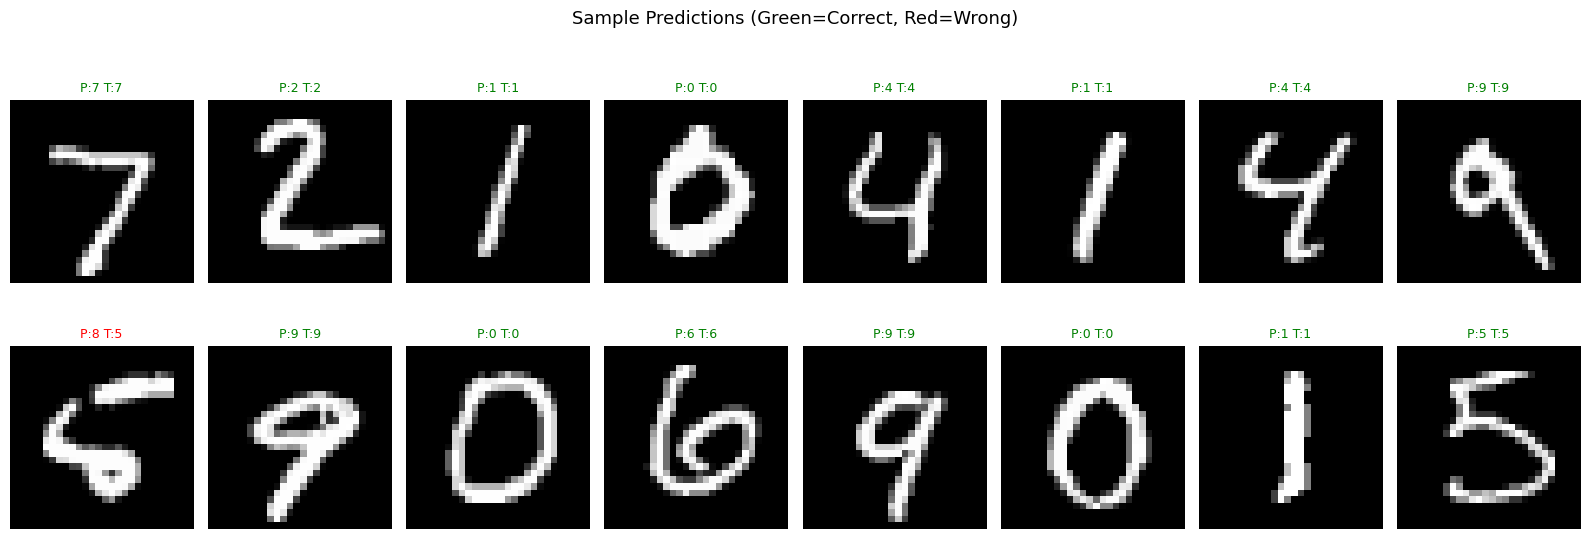

Predictions displayed!


In [37]:
model.eval()
images, labels = next(iter(test_loader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(16, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    pred  = preds[i].item()
    true  = labels[i].item()
    color = "green" if pred == true else "red"
    plt.title(f"P:{pred} T:{true}", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()
print("Predictions displayed!")

In [38]:
torch.save(model.state_dict(), "mnist_cnn_model.pth")
print("Model saved successfully!")

Model saved successfully!
